In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from sklearn.datasets import fetch_california_housing
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import SimpleImputer, KNNImputer, IterativeImputer
from sklearn.preprocessing import StandardScaler

In [2]:
dataset = fetch_california_housing()
print(type(dataset))
print(dataset.keys())
# print(dataset['DESCR'])
print(dataset.target_names)

<class 'sklearn.utils._bunch.Bunch'>
dict_keys(['data', 'target', 'frame', 'target_names', 'feature_names', 'DESCR'])
['MedHouseVal']


In [3]:
data = pd.DataFrame(dataset.data, columns=dataset.feature_names)
data['MedHouseValue'] = dataset.target

In [4]:
data.isna().sum()

MedInc           0
HouseAge         0
AveRooms         0
AveBedrms        0
Population       0
AveOccup         0
Latitude         0
Longitude        0
MedHouseValue    0
dtype: int64

In [7]:
mask = np.random.random(data.shape)
df = data.mask(mask < 0.1)
print(df.isna().sum())
print(df.isna().sum() / len(data) * 100)

MedInc           1996
HouseAge         2131
AveRooms         2117
AveBedrms        2104
Population       1993
AveOccup         2102
Latitude         2003
Longitude        2097
MedHouseValue    2091
dtype: int64
MedInc            9.670543
HouseAge         10.324612
AveRooms         10.256783
AveBedrms        10.193798
Population        9.656008
AveOccup         10.184109
Latitude          9.704457
Longitude        10.159884
MedHouseValue    10.130814
dtype: float64


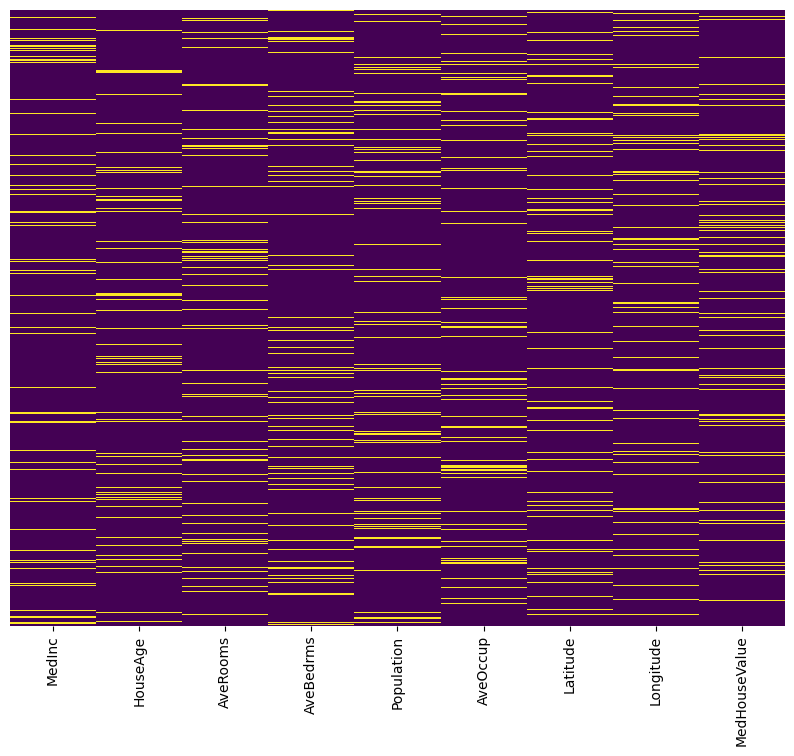

In [8]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.isna(), yticklabels=False, cbar=False, cmap='viridis')
plt.show()

In [9]:
df[['MedInc', 'HouseAge', 'AveRooms']].describe()

,MedInc,HouseAge,AveRooms
count,18644.000000,18509.000000,18523.000000
mean,3.870349,28.652007,5.436986
std,1.894013,12.579481,2.512379
min,0.499900,1.000000,0.888889
25%,2.563925,18.000000,4.444620
50%,3.536350,29.000000,5.233333
75%,4.746325,37.000000,6.054306
max,15.000100,52.000000,141.909091


AveRooms: threshold = 10.44, count = 186, percent=0.90%


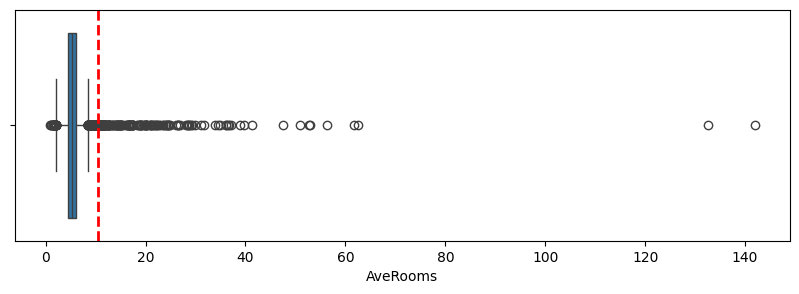

MedInc: threshold = 10.44, count = 199, percent=0.96%


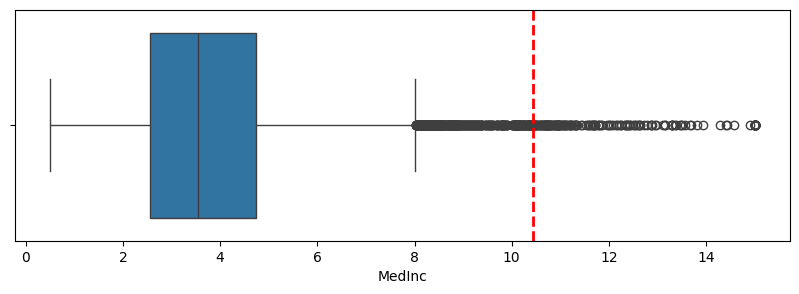

In [10]:
threshold = np.percentile(df["AveRooms"].dropna(), 99)
count = (df["AveRooms"] > threshold).sum()
print(f"AveRooms: threshold = {threshold:.2f}, count = {count}, percent={count/len(df) * 100:.2f}%")

plt.figure(figsize=(10, 3))
sns.boxplot(df, x='AveRooms')
plt.axvline(x=threshold, color='red', linestyle='--', linewidth=2)
plt.show()

threshold = np.percentile(df["AveRooms"].dropna(), 99)
count = (df["MedInc"] > threshold).sum()
print(f"MedInc: threshold = {threshold:.2f}, count = {count}, percent={count/len(df) * 100:.2f}%")

plt.figure(figsize=(10, 3))
sns.boxplot(df, x='MedInc')
plt.axvline(x=threshold, color='red', linestyle='--', linewidth=2)
plt.show()

# Deletion Approach

In [ ]:
df_deletion = df[['MedInc', 'HouseAge', 'AveRooms', 'MedHouseValue']].dropna()
features = df_deletion[['MedInc', 'HouseAge', 'AveRooms']]
target = df_deletion['MedHouseValue']
print(f"Filtered features: {len(features)}; original: {len(df)}.")
# df_deletion.isna().sum()

scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)
kernel = 'linear'
svr = SVR(kernel=kernel, C=1.0)
svr.fit(scaled_features, target)
predictions = svr.predict(scaled_features)

mse = mean_squared_error(target, predictions)
r2 = r2_score(target, predictions)
if kernel == 'linear':
    for feature, coef in zip(df_deletion.columns, svr.coef_[0]):
        print(f"{feature}: {coef:.4f}")

print(f"MSE: {mse:.4f}")
print(f"R2: {r2:.4f}")

plt.figure(figsize=(8, 5))
plt.scatter(target, predictions, alpha=.6)
plt.plot([target.min(), target.max()], [target.min(), target.max()],
        color='black', lw=2, ls='--')
plt.title(f'SVR on dropped df, MSE={mse:.4f}, R2={r2:.4f}')
plt.show()

In [ ]:
X = df[~df['MedHouseValue'].isna()]
print(f"X: {len(X)} / {len(df)}")

# Comparison of different Imputation Methods

In [11]:
def evaluate_model(features, target):
    result = {}
    
    scaler = StandardScaler()
    features = scaler.fit_transform(features)
    model = SVR(kernel='rbf', C=1.0)
    # model = LinearRegression()
    model.fit(features, target)
    predictions = model.predict(features)
    
    mse = mean_squared_error(target, predictions)
    r2 = r2_score(target, predictions)

    result['y_truth'] = target
    result['y_pred'] = predictions
    result['mse'] = mse
    result['r2'] = r2

    return result

def dropNA(df):
    df_deletion = df[['MedInc', 'HouseAge', 'AveRooms', 'MedHouseValue']].dropna()
    features = df_deletion[['MedInc', 'HouseAge', 'AveRooms']]
    target = df_deletion['MedHouseValue']
    result = evaluate_model(features, target)
    result['title'] = 'Drop NA'
    return result

def simple_imp(strategy, features, target):
    imputer = SimpleImputer(strategy=strategy)
    X_imputed = pd.DataFrame(imputer.fit_transform(features), columns=features.columns)

    result = evaluate_model(X_imputed, target)
    result['title'] = strategy.title().replace('_', ' ')
    return result

def knn_imp(features, target, n_neighbors=5):
    imputer = KNNImputer(n_neighbors=n_neighbors)
    X_imputed = pd.DataFrame(imputer.fit_transform(features), columns=features.columns)

    result = evaluate_model(X_imputed, target)
    result['title'] = f'KNN-{n_neighbors}'
    return result

def mice_imp(features, target, max_iter=10):
    imputer = IterativeImputer(max_iter=max_iter, random_state=37)
    X_imputed = pd.DataFrame(imputer.fit_transform(features), columns=features.columns)

    result = evaluate_model(X_imputed, target)
    result['title'] = f'MICE-{max_iter}'
    return result

In [12]:
import ipywidgets as widgets


def axes_plot(ax, store):
    target = store['y_truth']
    predictions = store['y_pred']
    title = store['title']
    mse = store['mse']
    r2 = store['r2']
    ax.scatter(target, predictions, alpha=.6)
    ax.plot([target.min(), target.max()], [target.min(), target.max()],
            color='black', lw=2, ls='--')
    ax.set_title(f'{title}: MSE={mse:.4f}, R2={r2:.4f}', {'fontsize':18})

def compare_methods(df):
    X = df[~df['MedHouseValue'].isna()]
    features = X[['MedInc', 'HouseAge', 'AveRooms']]
    target = X['MedHouseValue']

    results = []
    results.append(dropNA(X))
    results.append(simple_imp('mean', features, target))
    results.append(simple_imp('median', features, target))
    results.append(simple_imp('most_frequent', features, target))
    results.append(knn_imp(features, target, 10))
    results.append(mice_imp(features, target, 20))


    fig, axes = plt.subplots(2, 3, figsize=(20, 10))
    for i, res in enumerate(results):
        axes_plot(axes[divmod(i, 3)], res)

    plt.tight_layout()
    plt.show()


    methods = [r['title'] for r in results]
    mses = [r['mse'] for r in results]
    r2s = [r['r2'] for r in results]
    

    perf_df = pd.DataFrame({
        'Method': methods*2,
        'Metric': ['MSE']*len(mses) + ['R2']*len(r2s),
        'Value': mses + r2s
    })
    
    ax = sns.barplot(data=perf_df, x='Method', y='Value', hue='Metric', palette='tab10')
    ax.set_xlabel("")
    plt.title('Metrics Comparison')
    plt.show()

    return perf_df



output = widgets.Output()
def on_compare_button_click(b):
    with output:
        output.clear_output()
        perf_df = compare_methods(df)
        display(perf_df)

compare_button = widgets.Button(
    description="Compare Imputations")
compare_button.on_click(on_compare_button_click)
display(compare_button, output)

Button(description='Compare Imputations', style=ButtonStyle())

Output()

In [ ]:
print(perf_df)